# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [6]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

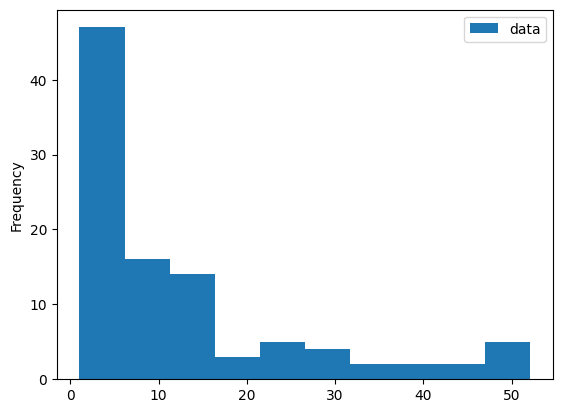

In [7]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

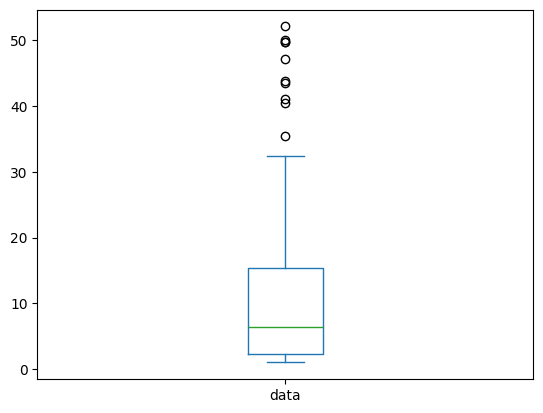

In [8]:
df.plot.box()

Histogram: You can see the skew here but not the outliers. It provides a clear view of the overall shape of the data's distribution, showing the exact frequency of items falling into specific price bins. Extreme outliers can unfortunately stretch the x-axis significantly, compressing the main bulk of the data into a single visual spike.

Box Plot: You can see the outliers clearly here. A con is that it hides the underlying distribution shape; for instance, you cannot tell if the data is bimodal.

In this situation, since you're trying to see how much more costlier the expensive drugs are in comparison to the rest the boxplot would be better. It visually isolates the outliers. To improve the format, I would add a clear title, label the Y-axis as "Price ($)", and change the outlier points to a brighter color like red so the administrator's eyes are immediately drawn to the expensive items and they visually stand out more. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

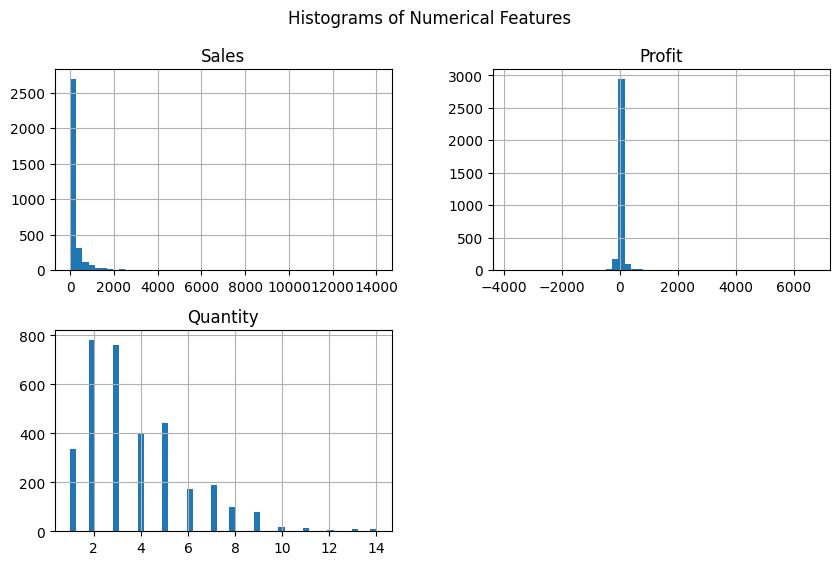

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('US Commerce')

#histograms for numerical features (Sales, Profit, Quantity)
df[['Sales', 'Profit', 'Quantity']].hist(bins=50, figsize=(10, 6))
plt.suptitle("Histograms of Numerical Features")
plt.show()

The sales graph is heavily right skewed and unimodal. Quantity is also right-skewed. 

Because the data is so right-skewed, large bin sizes force 99% of the data into the first visual bar (see the first graph for Sales). By decreasing the bin width or applying a log scale, we can actually see the smooth, bell-like distribution of the "normal" low-value orders that are otherwise hidden.

Adding on, the raw data does not appear normally distributed. It follows a Pareto (80/20) or Log-Normal distribution, typical of retail datasets where the majority of purchases are small.

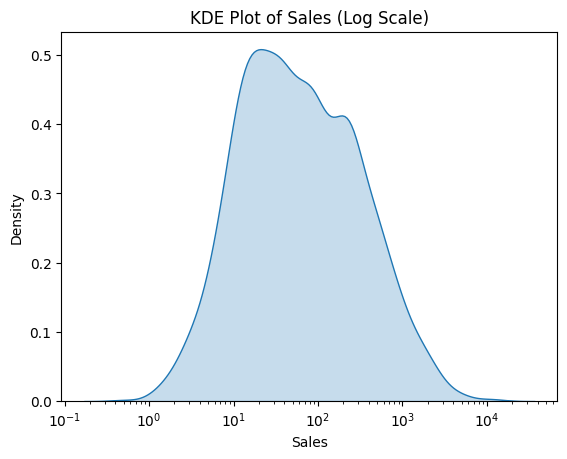

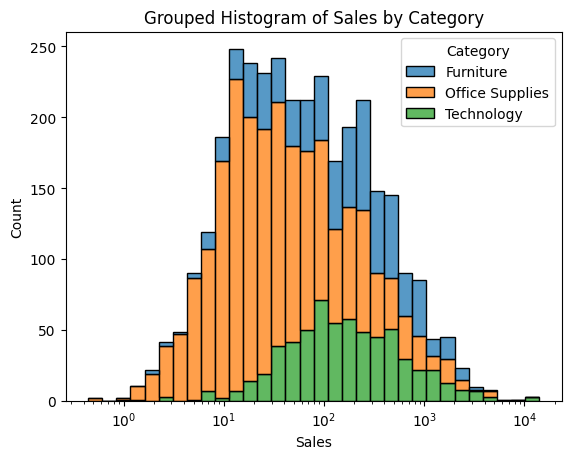

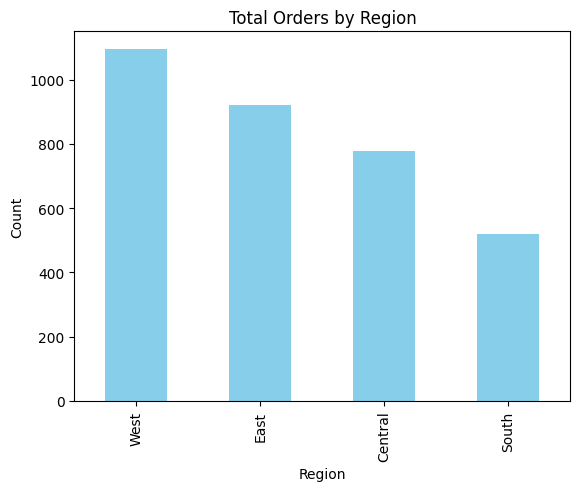

In [10]:

#KDE Plot for Sales (using log scale due to heavy skew)
sns.kdeplot(df['Sales'], log_scale=True, fill=True)
plt.title("KDE Plot of Sales (Log Scale)")
plt.show()

# grouped histograms (e.g., Sales grouped by Category)
sns.histplot(data=df, x='Sales', hue='Category', log_scale=True, multiple="stack")
plt.title("Grouped Histogram of Sales by Category")
plt.show()

# bar plot for total counts of categorical variable (e.g., Region)
df['Region'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Total Orders by Region")
plt.ylabel("Count")
plt.show()


In [11]:
# means, medians, and modes for numerical columns
mean_vals = df[['Sales', 'Profit', 'Quantity']].mean()
median_vals = df[['Sales', 'Profit', 'Quantity']].median()
mode_vals = df[['Sales', 'Profit', 'Quantity']].mode().iloc[0]

print("Means:\n", mean_vals)
print("\nMedians:\n", median_vals)
print("\nModes:\n", mode_vals)

Means:
 Sales       221.381418
Profit       28.212340
Quantity      3.766908
dtype: float64

Medians:
 Sales       53.8100
Profit       8.2968
Quantity     3.0000
dtype: float64

Modes:
 Sales       12.96
Profit       0.00
Quantity     2.00
Name: 0, dtype: float64


In [12]:
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())

              Sales     Quantity     Discount       Profit
count   3312.000000  3312.000000  3312.000000  3312.000000
mean     221.381418     3.766908     0.156467    28.212340
std      585.257531     2.221776     0.207429   241.864342
min        0.444000     1.000000     0.000000 -3839.990400
25%       17.018000     2.000000     0.000000     1.763200
50%       53.810000     3.000000     0.200000     8.296800
75%      205.105700     5.000000     0.200000    28.315125
max    13999.960000    14.000000     0.800000  6719.980800


This reveals that the median is just $54 vs. a mean of $221, a telltale sign of a long tail. Most orders are small, but a handful reach $14,000. The costlier items are the copiers. These are the extreme outliers. Both heavy negative and positive outliers in Profit depending on the Discount applied.

For Sales, the minimum is around $1 to $2, while the maximum spans into several thousands of dollars. Profit has a minimum deep in the negative hundreds/thousands (losses) and a maximum similarly high in the positive. Please note thae sales cannot be negative but the profit can be. 

The data is highly usable and reflects standard e-commerce behavior. There are mo missing or duplicate values. Most transactions are small (low value), but a few high-value enterprise or bulk orders drive a large portion of the revenue.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

I will be reproducing the Supplier Market Share graph. 

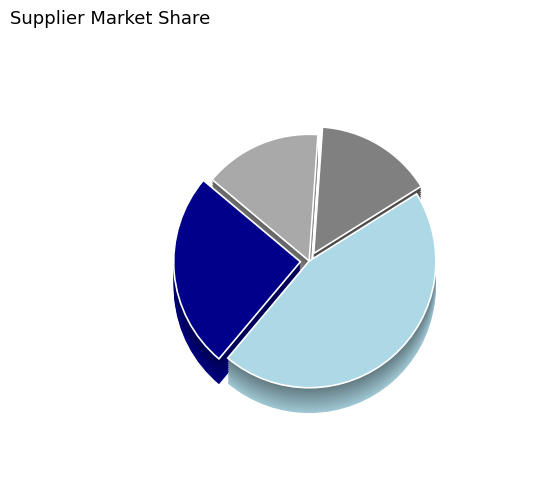

In [14]:
labels  = ['Supplier A', 'Supplier B', 'Supplier C', 'Supplier D']
sizes   = [25, 45, 15, 15]          # adjust to match your real data
colors  = ['darkblue', 'lightblue', 'gray', 'darkgray']
explode = (0.05, 0, 0.05, 0)        # pull A and C slightly out

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

depth   = 12          # how many shadow layers
drop    = 0.012       # how much each layer shifts downward

for d in range(depth, 0, -1):
    shade = [np.array(plt.matplotlib.colors.to_rgb(c)) * (0.55 + 0.03 * d)
             for c in colors]
    shade = [tuple(np.clip(s, 0, 1)) for s in shade]
    ax.pie(sizes, colors=shade, explode=explode,
           startangle=140,
           center=(0, -d * drop),
           radius=0.72)

wedges, _ = ax.pie(
    sizes,
    colors=colors,
    explode=explode,
    startangle=140,
    radius=0.72,
    wedgeprops=dict(linewidth=1.2, edgecolor='white'),
)

ax.set_title('Supplier Market Share', fontsize=13, loc='left',
             x=-0.18, y=1.02, fontweight='normal')

plt.tight_layout()
plt.savefig('supplier_market_share.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
